In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import anafibre as af
from anafibre.plotting import plot_xy_vector_field, animate_fields_xy
import astropy.units as u
import astropy.constants as co
from scipy.constants import epsilon_0 as eps0, mu_0 as mu0
plt.rcParams['text.usetex'] = True
from IPython.display import HTML

In [2]:
# This script sets up a step-index fibre with specific parameters.
fibre = af.StepIndexFibre(
    core_radius = 250*u.nm, 
    eps_core = 4,    
    eps_clad = 1,    
    mu_core  = 1,    
    mu_clad  = 1   
) 

In [3]:
mode = fibre.HE(ell=1, n=1, wl=1500*u.nm, a_plus=1, a_minus=1)
# mode = fibre.TE(n=1, wl=500*u.nm)
display(mode)

Mode,ℓ,m,λ [nm],V,ne,s1,s2,s3
HE11,1,1,IR1500.00,1.81,1.1645,1.00,0.00,0.00


In [4]:
display(mode.A, mode.B)

np.float64(0.7161186230419594)

np.complex128(-0.6979785940360119j)

In [5]:
r = 3 * fibre.core_radius  # Radius in micrometers
Nr = 600  # Number of points in radial direction
rho = np.linspace(0, r, Nr) * u.m
Nphi = int(2 * np.pi * (Nr-1))
phi = np.linspace(0, 2 * np.pi, Nphi)
Rho, Phi = np.meshgrid(rho, phi)

norm = (1/mode._power_normalisation(mode.A, mode.B))**2*u.W
power = mode.Power(rho=Rho, phi=Phi, z=0)*u.W
display(norm)
display(power.to(u.W))
display(power.to(u.W) / norm)

C:\Users\Sebastian\OneDrive - King's College London\Projects\2025_Anafibre\anafibre\src\anafibre\fields.py:251: RuntimeWarning: Using numeric estimate for modal power
  warnings.warn("Using numeric estimate for modal power", RuntimeWarning)


Using numeric estimate for modal power


<Quantity 0.00010188 W>

<Quantity 9.63622825e-05 W>

<Quantity 0.9458034>

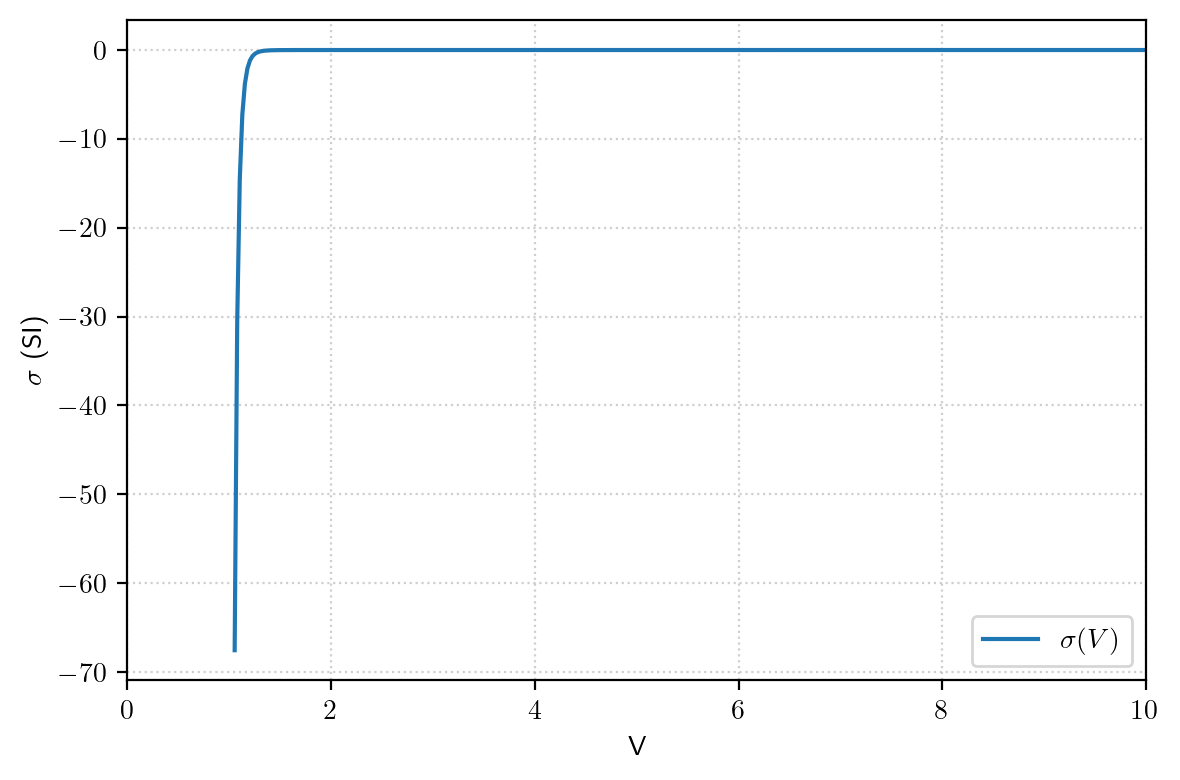

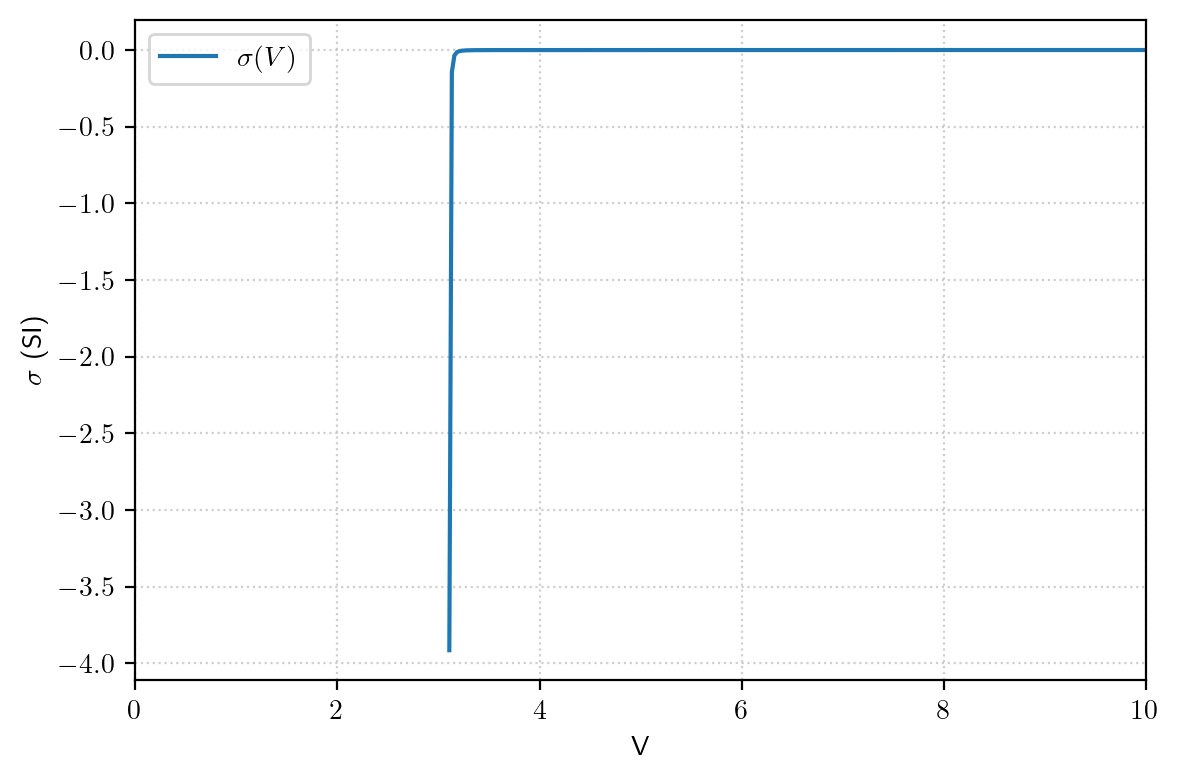

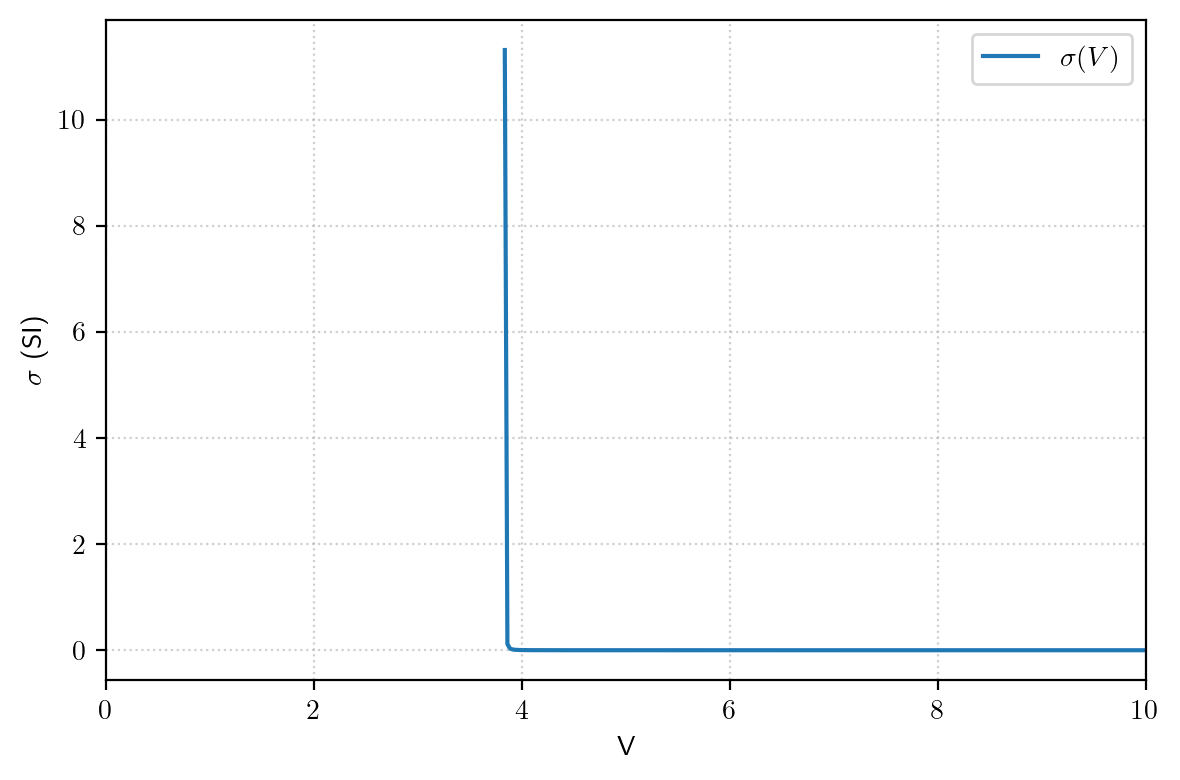

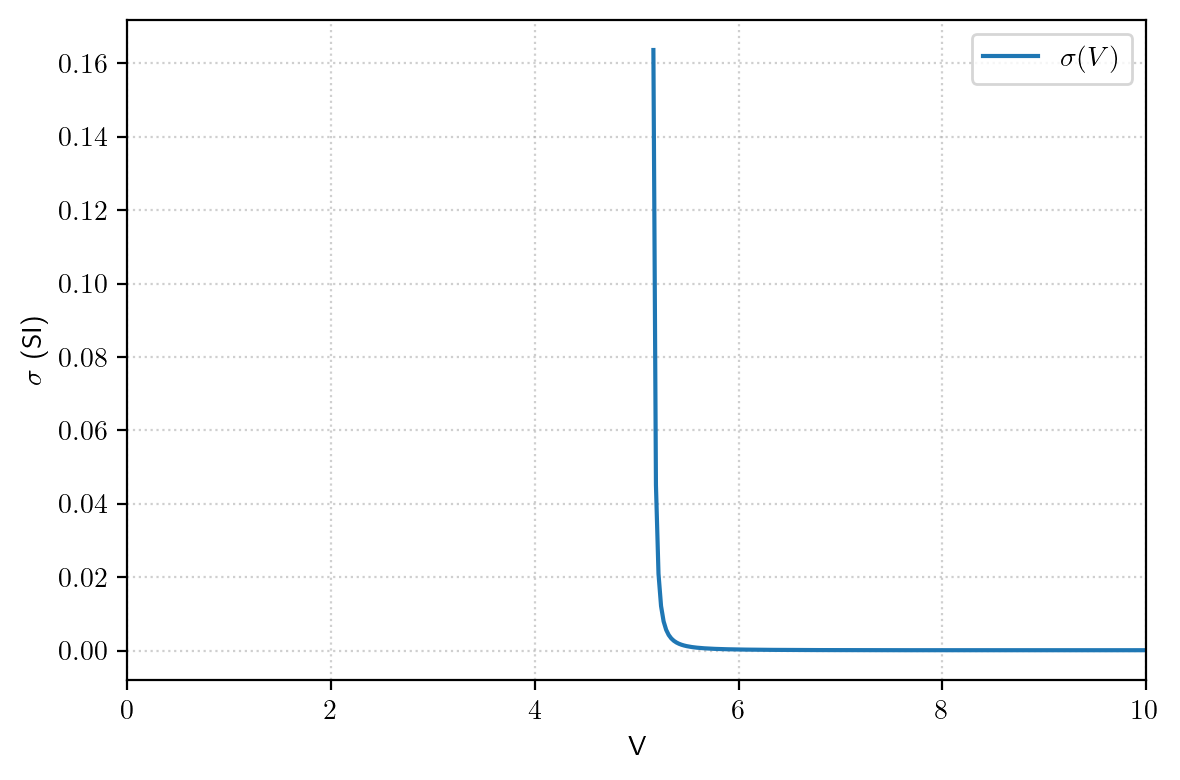

In [ ]:
af.plotting.plot_sigma_vs_V(fibre, 1, 1)
plt.show()
af.plotting.plot_sigma_vs_V(fibre, 2, 1)
plt.show()
af.plotting.plot_sigma_vs_V(fibre, 1, 2)
plt.show()
af.plotting.plot_sigma_vs_V(fibre, 2, 2)
plt.show()
af.plotting.plot_sigma_vs_V(fibre, 1, 3)
plt.show()
af.plotting.plot_sigma_vs_V(fibre, 3, 1)
plt.show()